In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#let's start our dummy porject
import numpy as np
import pandas as pd
orders=pd.read_csv('/content/drive/MyDrive/AI_ML_projects/user_privacy_preference/data/customer_orders_for_privacy_exercises.csv (1).zip')
iot=pd.read_csv('/content/drive/MyDrive/AI_ML_projects/user_privacy_preference/data/iot_example.csv (2).zip')
members=pd.read_csv('/content/drive/MyDrive/AI_ML_projects/user_privacy_preference/data/members.csv (1).zip')
browsing = pd.read_csv('/content/drive/MyDrive/AI_ML_projects/user_privacy_preference/data/users_web_browsing_for_privacy_exercises.csv (2).zip')
orders.head()

,order_number,user_id,email,street_address,city,state,num_items,total_price,timestamp
0,754,roy50,margaretwalker@example.com,8222 Jared Plains Suite 489,Millerfurt,Delaware,4,162,2022-07-31T13:53:42.176704
1,371,handerson,james63@example.org,39972 Isabella Haven Suite 670,Farrellport,Oklahoma,3,42,2022-08-03T17:54:12.176704
2,376,william55,sotopatricia@example.net,4418 Raymond Club,West Andreafort,Illinois,8,198,2022-08-05T18:54:45.176704
3,431,uking,cponce@example.com,369 Angela Green Suite 649,Whitemouth,Tennessee,6,90,2022-08-06T20:55:01.176704
4,713,tiffany94,kingelizabeth@example.net,3030 Kerr Streets Apt. 695,Hamptonhaven,Indiana,5,62,2022-08-09T22:55:50.176704


In [ ]:
iot.head()

,timestamp,username,temperature,heartrate,build,latest,note
0,2017-01-01T12:00:23,michaelsmith,12,67,4e6a7805-8faa-2768-6ef6-eb3198b483ac,0,interval
1,2017-01-01T12:01:09,kharrison,6,78,7256b7b0-e502-f576-62ec-ed73533c9c84,0,wake
2,2017-01-01T12:01:34,smithadam,5,89,9226c94b-bb4b-a6c8-8e02-cb42b53e9c90,0,NaN
3,2017-01-01T12:02:09,eddierodriguez,28,76,2599ac79-e5e0-5117-b8e1-57e5ced036f7,0,update
4,2017-01-01T12:02:36,kenneth94,29,62,122f1c6a-403c-2221-6ed1-b5caa08f11e0,0,user


In [ ]:
members.head()

,id,name,age,gender,education_level,zip_code,books_borrowed,favorite_genres,date_joined
0,421742,Alan,20,male,high-school-diploma,27509,22,Religion/spirituality;Mystery/thriller/crime,2021-08-26
1,338337,Tessa,27,female,bachelors-associate,27278,0,Science fiction;Graphic novels;History,2021-11-19
2,348835,Flaquita,52,female,high-school-diploma,27252,2,Cookbooks/food writing;Business;History,2021-04-23
3,871610,Eugene,9,male,up-to-high-school,27591,15,Classics/Literature;Biographies/memoirs,2021-09-02
4,793820,Ernesto,64,unspecified,high-school-diploma,27712,20,Biographies/memoirs,2021-02-23


In [ ]:
browsing.head()

,order_number,inbound_uri,browser_agent,ip,timestamp
0,9,weight-likely,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_8; ...,199.252.41.214,2022-07-31T13:53:49.548290
1,441,position-report,Opera/9.44.(X11; Linux x86_64; gv-GB) Presto/2...,179.25.93.144,2022-08-03T17:54:25.548290
2,72,tough-age-growth,Mozilla/5.0 (Windows; U; Windows NT 5.0) Apple...,125.124.68.154,2022-08-05T18:55:27.548290
3,168,way-right-century,Mozilla/5.0 (compatible; MSIE 6.0; Windows 98;...,22.43.48.185,2022-08-08T20:55:59.548290
4,539,event-might-society,Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like ...,30.219.140.88,2022-08-10T23:57:01.548290


In [ ]:
print(orders.columns)
print(iot.columns)
print(members.columns)
print(browsing.columns)

Index(['order_number', 'user_id', 'email', 'street_address', 'city', 'state',
       'num_items', 'total_price', 'timestamp'],
      dtype='object')
Index(['timestamp', 'username', 'temperature', 'heartrate', 'build', 'latest',
       'note'],
      dtype='object')
Index(['id', 'name', 'age', 'gender', 'education_level', 'zip_code',
       'books_borrowed', 'favorite_genres', 'date_joined'],
      dtype='object')
Index(['order_number', 'inbound_uri', 'browser_agent', 'ip', 'timestamp'], dtype='object')


In [ ]:
# as we can see ;
#order_number is common in (orders and browsing )
# user_ids and user_name  is common in (orders and iot )
# timestamp is common in (iot and browsing)
# date joined is common in (members and brwosing )   after little bit preprocessing

In [ ]:
#merging orders and browsing
orders_browsing = pd.merge(
    orders,
    browsing,
    on='order_number',
    how='inner',
    suffixes=('_order', '_browsing')
)
# merging already order_brwosing woth iot
combined_activity = pd.merge(
    orders_browsing,
    iot,
    # left_on bcz they have doffernet  column names  so it should be keep in mind
    left_on='user_id',
    right_on='username',
    how='inner',
    suffixes=('_activity', '_iot')
)
combined_activity.head()

,order_number,user_id,email,street_address,city,state,num_items,total_price,timestamp_order,inbound_uri,browser_agent,ip,timestamp_browsing,timestamp,username,temperature,heartrate,build,latest,note
0,754,roy50,margaretwalker@example.com,8222 Jared Plains Suite 489,Millerfurt,Delaware,4,162,2022-07-31T13:53:42.176704,green-executive,Mozilla/5.0 (X11; Linux i686; rv:1.9.7.20) Gec...,179.219.125.40,2028-06-25T01:07:39.548290,2017-02-09T20:14:26,roy50,26,67,152bea9f-ec92-e685-0ab6-b317d1a03ea1,1,interval
1,754,roy50,margaretwalker@example.com,8222 Jared Plains Suite 489,Millerfurt,Delaware,4,162,2022-07-31T13:53:42.176704,president-hold,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,16.132.214.145,2028-11-13T13:42:45.548290,2017-02-09T20:14:26,roy50,26,67,152bea9f-ec92-e685-0ab6-b317d1a03ea1,1,interval
2,754,roy50,margaretwalker@example.com,8222 Jared Plains Suite 489,Millerfurt,Delaware,4,162,2022-07-31T13:53:42.176704,box-cup-hair-their,Mozilla/5.0 (compatible; MSIE 7.0; Windows NT ...,24.78.234.217,2031-11-06T02:14:37.548290,2017-02-09T20:14:26,roy50,26,67,152bea9f-ec92-e685-0ab6-b317d1a03ea1,1,interval
3,754,roy50,margaretwalker@example.com,8222 Jared Plains Suite 489,Millerfurt,Delaware,4,162,2022-07-31T13:53:42.176704,use-station-see,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,175.0.200.247,2042-01-02T21:21:24.548290,2017-02-09T20:14:26,roy50,26,67,152bea9f-ec92-e685-0ab6-b317d1a03ea1,1,interval
4,754,roy50,margaretwalker@example.com,8222 Jared Plains Suite 489,Millerfurt,Delaware,4,162,2022-07-31T13:53:42.176704,full-safe-ready,Opera/8.57.(X11; Linux i686; ca-FR) Presto/2.9...,64.247.197.157,2043-12-05T06:17:38.548290,2017-02-09T20:14:26,roy50,26,67,152bea9f-ec92-e685-0ab6-b317d1a03ea1,1,interval


In [ ]:
print(combined_activity.shape)

(187307, 20)


In [ ]:
# so now we are left with members only becuse we cannot directly join this csv with combined_activity
# they don't have any column common ,so leave that fu** alone for now



In [ ]:
roy_data = combined_activity[combined_activity['user_id'] == 'roy50']
print(roy_data.shape)
print(roy_data)
#as the roy is repeating 11 times ,we should do something for that like taking mean of some values and cutout waste information


(11, 20)
    order_number user_id                       email  \
0            754   roy50  margaretwalker@example.com   
1            754   roy50  margaretwalker@example.com   
2            754   roy50  margaretwalker@example.com   
3            754   roy50  margaretwalker@example.com   
4            754   roy50  margaretwalker@example.com   
5            754   roy50  margaretwalker@example.com   
6            754   roy50  margaretwalker@example.com   
7            754   roy50  margaretwalker@example.com   
8            754   roy50  margaretwalker@example.com   
9            754   roy50  margaretwalker@example.com   
10           754   roy50  margaretwalker@example.com   

                 street_address        city     state  num_items  total_price  \
0   8222 Jared Plains Suite 489  Millerfurt  Delaware          4          162   
1   8222 Jared Plains Suite 489  Millerfurt  Delaware          4          162   
2   8222 Jared Plains Suite 489  Millerfurt  Delaware          4          1

In [ ]:
# once again we will summmarise our data
browsing_new= browsing.groupby('order_number').agg(
    total_page_views=('inbound_uri', 'count'),
    latest_browsing_time=('timestamp', 'max')
).reset_index()


iot_new = iot.groupby('username').agg(
    avg_temperature=('temperature', 'mean'),
    avg_heartrate=('heartrate', 'mean'),
    total_iot_logs=('note', 'count')
).reset_index()


# we will merge this again so it can be easily
clean_data = pd.merge(orders, browsing_new, on='order_number', how='left')
clean_data = pd.merge(clean_data, iot_new, left_on='user_id', right_on='username', how='left')
clean_data.drop(columns=['username'], inplace=True)

print(clean_data.shape)
clean_data.head()
# clearly our new data is mway more cleaner and summarised than the previous one that i halfly processsed and repeated

(10000, 14)


,order_number,user_id,email,street_address,city,state,num_items,total_price,timestamp,total_page_views,latest_browsing_time,avg_temperature,avg_heartrate,total_iot_logs
0,754,roy50,margaretwalker@example.com,8222 Jared Plains Suite 489,Millerfurt,Delaware,4,162,2022-07-31T13:53:42.176704,11,2083-01-22T23:42:28.548290,26.000000,67.000000,1.0
1,371,handerson,james63@example.org,39972 Isabella Haven Suite 670,Farrellport,Oklahoma,3,42,2022-08-03T17:54:12.176704,4,2082-11-08T23:21:24.548290,17.800000,75.700000,9.0
2,376,william55,sotopatricia@example.net,4418 Raymond Club,West Andreafort,Illinois,8,198,2022-08-05T18:54:45.176704,7,2078-09-28T03:41:26.548290,16.666667,74.833333,4.0
3,431,uking,cponce@example.com,369 Angela Green Suite 649,Whitemouth,Tennessee,6,90,2022-08-06T20:55:01.176704,11,2077-12-31T14:30:58.548290,20.454545,75.636364,9.0
4,713,tiffany94,kingelizabeth@example.net,3030 Kerr Streets Apt. 695,Hamptonhaven,Indiana,5,62,2022-08-09T22:55:50.176704,12,2080-05-30T18:18:44.548290,NaN,NaN,NaN


In [ ]:
clean_data.iloc[:, 13] = clean_data.iloc[:, 13].fillna(0)
# i think we should replace nana values with average of the whole column to avoid any complications
clean_data.iloc[:, 11] = clean_data.iloc[:, 11].fillna(clean_data.iloc[:, 11].mean())# null->temperatur e column ,replaced by mean
clean_data.iloc[:, 12] = clean_data.iloc[:, 12].fillna(clean_data.iloc[:, 12].mean()) # null->hear rate column is replaced by mean
clean_data.head()
# now all tha nan values are replaced

,order_number,user_id,email,street_address,city,state,num_items,total_price,timestamp,total_page_views,latest_browsing_time,avg_temperature,avg_heartrate,total_iot_logs
0,754,roy50,margaretwalker@example.com,8222 Jared Plains Suite 489,Millerfurt,Delaware,4,162,2022-07-31T13:53:42.176704,11,2083-01-22T23:42:28.548290,26.000000,67.000000,1.0
1,371,handerson,james63@example.org,39972 Isabella Haven Suite 670,Farrellport,Oklahoma,3,42,2022-08-03T17:54:12.176704,4,2082-11-08T23:21:24.548290,17.800000,75.700000,9.0
2,376,william55,sotopatricia@example.net,4418 Raymond Club,West Andreafort,Illinois,8,198,2022-08-05T18:54:45.176704,7,2078-09-28T03:41:26.548290,16.666667,74.833333,4.0
3,431,uking,cponce@example.com,369 Angela Green Suite 649,Whitemouth,Tennessee,6,90,2022-08-06T20:55:01.176704,11,2077-12-31T14:30:58.548290,20.454545,75.636364,9.0
4,713,tiffany94,kingelizabeth@example.net,3030 Kerr Streets Apt. 695,Hamptonhaven,Indiana,5,62,2022-08-09T22:55:50.176704,12,2080-05-30T18:18:44.548290,17.089604,74.499444,0.0


In [ ]:
clean_data['timestamp'] = pd.to_datetime(clean_data['timestamp'])
clean_data['latest_browsing_time'] = pd.to_datetime(clean_data['latest_browsing_time'])
# this will calaulate a new column of time/duration named activity_duration_days
clean_data['activity_duration_days'] = (clean_data['latest_browsing_time'] - clean_data['timestamp']).dt.days
#intorducing two dummy variable to comapre and for a new row named consent
def set_consent_tier(row):
    if row['total_iot_logs'] > 3 and row['total_price'] > 100:
        return 'restricted'
    elif row['total_page_views'] > 5:
        return 'cannot share data'
    else:
        return 'can share data'
# creating a whole new output roow
clean_data['consent_tier']=clean_data.apply(set_consent_tier,axis=1)

print(clean_data['consent_tier'].value_counts())


consent_tier
cannot share data    8588
can share data        730
restricted            682
Name: count, dtype: int64


In [ ]:
#finally data preprocessing is done
clean_data.head()

,order_number,user_id,email,street_address,city,state,num_items,total_price,timestamp,total_page_views,latest_browsing_time,avg_temperature,avg_heartrate,total_iot_logs,activity_duration_days,consent_tier
0,754,roy50,margaretwalker@example.com,8222 Jared Plains Suite 489,Millerfurt,Delaware,4,162,2022-07-31 13:53:42.176704,11,2083-01-22 23:42:28.548290,26.000000,67.000000,1.0,22090,cannot share data
1,371,handerson,james63@example.org,39972 Isabella Haven Suite 670,Farrellport,Oklahoma,3,42,2022-08-03 17:54:12.176704,4,2082-11-08 23:21:24.548290,17.800000,75.700000,9.0,22012,can share data
2,376,william55,sotopatricia@example.net,4418 Raymond Club,West Andreafort,Illinois,8,198,2022-08-05 18:54:45.176704,7,2078-09-28 03:41:26.548290,16.666667,74.833333,4.0,20507,restricted
3,431,uking,cponce@example.com,369 Angela Green Suite 649,Whitemouth,Tennessee,6,90,2022-08-06 20:55:01.176704,11,2077-12-31 14:30:58.548290,20.454545,75.636364,9.0,20235,cannot share data
4,713,tiffany94,kingelizabeth@example.net,3030 Kerr Streets Apt. 695,Hamptonhaven,Indiana,5,62,2022-08-09 22:55:50.176704,12,2080-05-30 18:18:44.548290,17.089604,74.499444,0.0,21113,cannot share data


In [ ]:
# now we will step into model trainign

from sklearn.model_selection import train_test_split

X = clean_data[['num_items', 'total_price', 'total_page_views', 'avg_temperature', 'avg_heartrate', 'total_iot_logs', 'activity_duration_days']]
y = clean_data['consent_tier']
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
# out data has been suceesfully divided
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 7)
(2000, 7)
(8000,)
(2000,)


In [ ]:
# trying randomforestclassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  classification_report,accuracy_score
model=RandomForestClassifier(random_state=30)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


print("accuracy :", accuracy_score(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))


accuracy : 1.0
classification report:
                    precision    recall  f1-score   support

   can share data       1.00      1.00      1.00       163
cannot share data       1.00      1.00      1.00      1695
       restricted       1.00      1.00      1.00       142

         accuracy                           1.00      2000
        macro avg       1.00      1.00      1.00      2000
     weighted avg       1.00      1.00      1.00      2000



In [ ]:
# now we will do same thing using gradient boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

model2=GradientBoostingClassifier(random_state=30)
model2.fit(X_train,y_train)
y_pred2=model2.predict(X_test)

print("accuracy: ",  accuracy_score(y_test,y_pred2))
print("classification report:\n",classification_report(y_test,y_pred2))

accuracy:  1.0
classification report:
                    precision    recall  f1-score   support

   can share data       1.00      1.00      1.00       163
cannot share data       1.00      1.00      1.00      1695
       restricted       1.00      1.00      1.00       142

         accuracy                           1.00      2000
        macro avg       1.00      1.00      1.00      2000
     weighted avg       1.00      1.00      1.00      2000



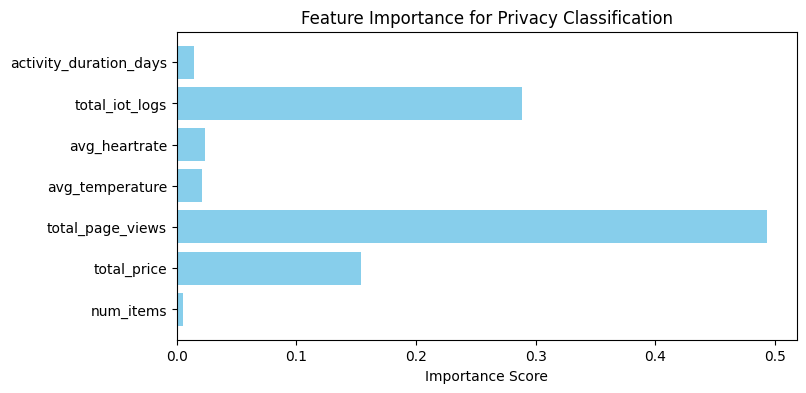

In [ ]:
# let's do some plotting stuff
import matplotlib.pyplot as plt

# Get feature importance from RandomForest
importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 4))
plt.barh(feature_names, importances, color='skyblue')
plt.title("Feature Importance for Privacy Classification")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
#let's also try this with logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
model=LogisticRegression(random_state=30)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


# so this is accuracy is relaastic ,but above two are overfitted  i think so
print("accuracy: ", accuracy_score(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))

accuracy:  0.85
classification report:
                    precision    recall  f1-score   support

   can share data       0.56      0.03      0.06       163
cannot share data       0.86      0.99      0.92      1695
       restricted       0.49      0.16      0.24       142

         accuracy                           0.85      2000
        macro avg       0.63      0.39      0.41      2000
     weighted avg       0.81      0.85      0.80      2000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# trying  support vector machine
from sklearn.svm import SVC
from sklearn.metrics import  classification_report,accuracy_score
# we also  have to pass a parameter kernel also
model=SVC(  kernel ='rbf',random_state=30)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


print("accuracy :", accuracy_score(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))


accuracy : 0.849
classification report:
                    precision    recall  f1-score   support

   can share data       1.00      0.02      0.04       163
cannot share data       0.85      1.00      0.92      1695
       restricted       0.00      0.00      0.00       142

         accuracy                           0.85      2000
        macro avg       0.62      0.34      0.32      2000
     weighted avg       0.80      0.85      0.78      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# trying k -nearest neighbour also
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
model=KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


print("accuracy: ", accuracy_score(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))

accuracy:  0.8355
classification report:
                    precision    recall  f1-score   support

   can share data       0.25      0.05      0.08       163
cannot share data       0.85      0.98      0.91      1695
       restricted       0.15      0.01      0.03       142

         accuracy                           0.84      2000
        macro avg       0.42      0.35      0.34      2000
     weighted avg       0.75      0.84      0.78      2000



In [ ]:
# let's try decisoin tree
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


print("accuracy: ", accuracy_score(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))

accuracy:  0.9995
classification report:
                    precision    recall  f1-score   support

   can share data       0.99      1.00      1.00       163
cannot share data       1.00      1.00      1.00      1695
       restricted       1.00      0.99      1.00       142

         accuracy                           1.00      2000
        macro avg       1.00      1.00      1.00      2000
     weighted avg       1.00      1.00      1.00      2000

